In [ ]:
import os

cache_dir = "../../huggingface_cache"
os.environ['HF_HOME'] = cache_dir

# Create the directory if it doesn't exist
os.makedirs(cache_dir, exist_ok=True)

print(f"✅ Hugging Face cache directory is now set to: {os.environ['HF_HOME']}")

✅ Hugging Face cache directory is now set to: ../../huggingface_cache


In [2]:
import json
import requests
import networkx as nx
import numpy as np
import time
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
import os
import sys
import subprocess
from huggingface_hub import login

# Add the cloned repository to the Python path
sys.path.append('repository/circuit-tracer')
sys.path.append('repository/circuit-tracer/demos')

# This will prompt you for your token
# login()
login(token="")

In [3]:
INPUT_GRAPH_FILE = './graphs/dallas-austin-subgraph.json'

# The Chain-of-Thought we want to match against
TARGET_COT = "Dallas is a major city located in the state of Texas. The capital city of Texas is Austin."

# Neuronpedia settings for Gemma 2 2B Transcoders
# If your graph uses a different width (e.g. 131k), change '16k' to that number.
MODEL_ID = 'google/gemma-2-2b-it'
SAE_SUFFIX = "AXBENCH-REFT-R1-RES-16K" #"gemmascope-transcoder-16k"

In [4]:
# ==========================================
# 1. HELPER: FETCH EXPLANATIONS
# ==========================================
explanation_cache = {}

def get_feature_description(layer, feature_index):
    """
    Fetches the text explanation for a feature from Neuronpedia API.
    Uses a cache to avoid re-fetching the same feature multiple times.
    """
    # 1. Handle Embedding Layer (Input Tokens)
    if layer in ['E', 'embedding']:
        # For input tokens, we don't fetch from API. 
        # We'll just return a placeholder that will be filled with the token text later.
        return None 

    # 2. Check Cache
    cache_key = (layer, feature_index)
    if cache_key in explanation_cache:
        return explanation_cache[cache_key]

    # 3. Construct API URL
    # Format: https://www.neuronpedia.org/api/feature/{model}/{layer}-{suffix}/{index}
    sae_id = f"{layer}-{SAE_SUFFIX}"
    url = f"https://www.neuronpedia.org/api/feature/{MODEL_ID}/{sae_id}/{feature_index}"
    print(url)

    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            # Try to find the auto-interp explanation
            explanations = data.get('explanations', [])
            if explanations:
                # usually the first one is the best/default
                desc = explanations[0].get('description', "No description")
            else:
                desc = "Unknown Feature"
        else:
            print(f"  [!] API Error {response.status_code} for L{layer}:{feature_index}")
            desc = "Unknown Feature"
            
    except Exception as e:
        print(f"  [!] Request failed for L{layer}:{feature_index}: {e}")
        desc = "Unknown Feature"

    # 4. Save to Cache and Return
    explanation_cache[cache_key] = desc
    time.sleep(0.05) # Be polite to the API
    return desc

In [5]:
# ==========================================
# 2. MAIN LOGIC
# ==========================================
def main():
    print(f"loading graph from {INPUT_GRAPH_FILE}...")
    try:
        with open(INPUT_GRAPH_FILE, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print("Error: File not found. Make sure you run the 'Top N' extraction script first!")
        return

    # --- A. Build NetworkX Graph ---
    G = nx.DiGraph()
    
    # We need to map node_id to its data for easy lookup
    node_lookup = {}
    
    for node in data['nodes']:
        G.add_node(node['node_id'])
        node_lookup[node['node_id']] = node

    for link in data['links']:
        G.add_edge(link['source'], link['target'], weight=link.get('weight', 0))

    # --- B. Find Start (Input) and End (Output) Nodes ---
    # Input nodes are usually Layer 'E'
    input_nodes = [n['node_id'] for n in data['nodes'] if str(n['layer']) in ['E', 'embedding']]
    
    # Output node is usually the last one in the list or has specific metadata
    # We assume the user wants paths to the final node in the JSON
    target_node = data['nodes'][-1]['node_id']
    
    print(f"Graph stats: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")
    print(f"Tracing paths from {len(input_nodes)} input tokens to target: {target_node}...")

    # --- C. Extract All Paths ---
    all_paths = []
    for start_node in input_nodes:
        try:
            # simple_paths finds all paths without cycles
            # cutoff=10 prevents infinite hanging if graph is complex
            paths = list(nx.all_simple_paths(G, source=start_node, target=target_node, cutoff=12))
            all_paths.extend(paths)
        except Exception:
            continue

    print(f"Found {len(all_paths)} total paths.")
    if len(all_paths) == 0:
        print("No paths found. Check if your subgraph is connected (increase Top N if needed).")
        return

    # --- D. Convert Paths to Text Descriptions ---
    print("Fetching feature explanations from Neuronpedia...")
    
    path_texts = []
    valid_paths = [] # Keep track of paths that we successfully process

    for i, path in enumerate(all_paths):
        description_sequence = []
        
        for node_id in path:
            node = node_lookup[node_id]
            layer = str(node.get('layer'))
            
            if layer in ['E', 'embedding']:
                # For input tokens, use the token text if available (e.g. from context)
                # Or just say "Input Token"
                # If your JSON has 'clerp' or text labels for inputs, use them here.
                # Assuming 'ctx_idx' or similar might hint at the word, but usually 
                # you have to infer it or it's hardcoded. 
                # For now, we label it generically to avoid errors.
                desc = f"Input Token (Layer {layer})"
            else:
                feature_idx = node.get('feature')
                desc = get_feature_description(layer, feature_idx)
            
            description_sequence.append(desc)
        
        # Join them: "Input -> Concept A -> Concept B -> Output"
        full_text = " -> ".join(description_sequence)
        path_texts.append(full_text)
        valid_paths.append(path)
        
        if i % 10 == 0:
            print(f"  Processed {i}/{len(all_paths)} paths...")

    # --- E. Calculate Embeddings & Similarity ---
    print("\nLoading embedding model (this downloads ~100MB the first time)...")
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    
    print("Embedding paths...")
    path_embeddings = embedder.encode(path_texts)
    
    print(f"Embedding CoT: '{TARGET_COT}'")
    cot_embedding = embedder.encode([TARGET_COT])
    
    # Compute Cosine Similarity
    # cot_embedding is (1, 384), path_embeddings is (N, 384)
    similarities = cosine_similarity(cot_embedding, path_embeddings)[0]
    
    # --- F. Results ---
    # Sort by score
    top_indices = np.argsort(similarities)[::-1][:5] # Get top 5
    
    print("\n" + "="*60)
    print("RESULTS: TOP MATCHING SUBGRAPHS")
    print("="*60)
    
    for rank, idx in enumerate(top_indices):
        score = similarities[idx]
        text = path_texts[idx]
        print(f"\nRANK {rank+1} (Similarity: {score:.4f})")
        print(f"Path Description:\n  {text}")
        print("-" * 30)

if __name__ == "__main__":
    main()

loading graph from ./graphs/dallas-austin-subgraph.json...
Graph stats: 84 nodes, 775 edges.
Tracing paths from 3 input tokens to target: 27_235248_7...
Found 804429 total paths.
Fetching feature explanations from Neuronpedia...
https://www.neuronpedia.org/api/feature/google/gemma-2-2b-it/0-AXBENCH-REFT-R1-RES-16K/23691285
  [!] API Error 404 for L0:23691285
https://www.neuronpedia.org/api/feature/google/gemma-2-2b-it/4-AXBENCH-REFT-R1-RES-16K/44467160
  [!] API Error 404 for L4:44467160
https://www.neuronpedia.org/api/feature/google/gemma-2-2b-it/5-AXBENCH-REFT-R1-RES-16K/208329
  [!] API Error 404 for L5:208329
https://www.neuronpedia.org/api/feature/google/gemma-2-2b-it/7-AXBENCH-REFT-R1-RES-16K/42076543
  [!] API Error 404 for L7:42076543
https://www.neuronpedia.org/api/feature/google/gemma-2-2b-it/8-AXBENCH-REFT-R1-RES-16K/107142832
  [!] API Error 404 for L8:107142832
https://www.neuronpedia.org/api/feature/google/gemma-2-2b-it/9-AXBENCH-REFT-R1-RES-16K/53338946
  [!] API Error 4

KeyboardInterrupt: 

In [15]:
import json
import networkx as nx

# CONFIGURATION
INPUT_GRAPH_FILE = './graphs/dallas-austin-subgraph.json'

def main():
    print(f"Loading graph from {INPUT_GRAPH_FILE}...")
    try:
        with open(INPUT_GRAPH_FILE, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print("Error: File not found.")
        return

    # 1. Build Graph
    G = nx.DiGraph()
    node_lookup = {}
    
    for node in data['nodes']:
        G.add_node(node['node_id'], influence=node.get('influence', 0), layer=node.get('layer'))
        node_lookup[node['node_id']] = node

    for link in data['links']:
        # Use edge weight (attribution) as the cost/score
        # We invert it because standard algorithms find the *shortest* path (min weight)
        # but we want the *highest* attribution.
        weight = link.get('weight', 0)
        if weight > 0:
            G.add_edge(link['source'], link['target'], weight=weight)

    # 2. Identify Start and End
    # Input: Embedding layer or Layer 0
    input_nodes = [n for n, attr in G.nodes(data=True) if str(attr['layer']) in ['E', 'embedding', '0']]
    
    # Output: The final node in the JSON list (usually the target logit)
    target_node = data['nodes'][-1]['node_id']
    
    print(f"Tracing influence from {len(input_nodes)} inputs to target {target_node}...")

    # 3. Find Most Influential Paths
    # We find all simple paths and sum their edge weights to see which path carried the most signal
    all_paths = []
    
    for start_node in input_nodes:
        try:
            # Find paths
            raw_paths = list(nx.all_simple_paths(G, source=start_node, target=target_node, cutoff=10))
            
            for path in raw_paths:
                # Calculate Total Path Influence (Sum of edge weights)
                total_score = 0
                for i in range(len(path) - 1):
                    u, v = path[i], path[i+1]
                    total_score += G[u][v]['weight']
                
                all_paths.append((total_score, path))
        except:
            continue

    # 4. Sort and Display
    # Sort by score descending
    all_paths.sort(key=lambda x: x[0], reverse=True)
    
    print("\n" + "="*50)
    print("TOP INFLUENTIAL 'SOLUTION' PATHS")
    print("="*50)
    
    for rank, (score, path) in enumerate(all_paths[:5]):
        print(f"\nRANK {rank+1} (Total Attribution: {score:.4f})")
        
        # Print path with Feature IDs (since we don't have text)
        readable_path = []
        for node_id in path:
            node = node_lookup[node_id]
            layer = node.get('layer')
            feat = node.get('feature')
            
            if str(layer) in ['E', 'embedding']:
                label = f"Input Token"
            else:
                label = f"L{layer}:Feature_{feat}"
            readable_path.append(label)
            
        print(" -> ".join(readable_path))
        print("-" * 30)

if __name__ == "__main__":
    main()

Loading graph from ./graphs/dallas-austin-subgraph.json...
Tracing influence from 6 inputs to target 27_235248_7...

TOP INFLUENTIAL 'SOLUTION' PATHS

RANK 1 (Total Attribution: 71.8667)
Input Token -> L17:Feature_88026528 -> L19:Feature_96750985 -> L21:Feature_118402944 -> L22:Feature_91469552 -> L24:Feature_92024936 -> L27:Feature_235248
------------------------------

RANK 2 (Total Attribution: 71.1914)
Input Token -> L17:Feature_88026528 -> L22:Feature_4534543 -> L24:Feature_92024936 -> L27:Feature_235248
------------------------------

RANK 3 (Total Attribution: 71.1685)
Input Token -> L17:Feature_88026528 -> L19:Feature_96750985 -> L21:Feature_118402944 -> L22:Feature_91469552 -> L23:Feature_96028987 -> L27:Feature_235248
------------------------------

RANK 4 (Total Attribution: 70.9941)
Input Token -> L17:Feature_88026528 -> L19:Feature_96750985 -> L21:Feature_118402944 -> L22:Feature_91469552 -> L25:Feature_15116725 -> L27:Feature_235248
------------------------------

RANK 5 

In [26]:
def get_neuronpedia_concept(model_id, sae_id, feature_idx):
    """
    Fetches the text description of a feature from Neuronpedia.
    
    Args:
        model_id (str): e.g., "gemma-2-2b"
        sae_id (str): The specific set ID. e.g., "20-gemmascope-res-16k" 
                      OR for your graph likely: "layer_0-transcoder-mntss"
        feature_idx (int): The feature ID (e.g., 10004)
        
    Returns:
        str: The description (e.g., "Concept related to Texas")
    """
    # 1. Construct the API URL (Notice the added '/api/feature' part)
    url = f"https://www.neuronpedia.org/api/feature/{model_id}/{sae_id}/{feature_idx}"
    
    try:
        # 2. Fetch Data
        response = requests.get(url, timeout=3)
        
        if response.status_code == 200:
            data = response.json()
            # 3. Extract the text explanation
            explanations = data.get('explanations', [])
            if explanations:
                return explanations[0].get('description')
            return "No description available"
        else:
            return f"Error: {response.status_code}"
            
    except Exception as e:
        return f"Request Failed: {e}"

# --- TEST IT ---
# Try fetching the concept from your example
description = get_neuronpedia_concept(
    model_id="gemma-2-2b", 
    sae_id= "1-gemmascope-transcoder-16k", # Make sure this matches your graph's layer! "gemmascope-jumprelu-n82-transcoder", #
    feature_idx=3655
)
print(f"Concept: {description}")

Concept: the word "principle"


In [37]:
  import json
  import requests

  def parse_node_id(node_id):
      """
      Parses node_id to extract layer and feature index.

      Args:
          node_id (str): Format "{layer}_{feat_idx}_{position}" e.g., "0_14725_2"

      Returns:
          tuple: (layer, feat_idx, position)
      """
      parts = node_id.split('_')
      if len(parts) == 3:
          layer = int(parts[0])
          feat_idx = int(parts[1])
          position = int(parts[2])
          return layer, feat_idx, position
      return None, None, None

  def get_neuronpedia_concept(model_id, layer, feature_idx):
      """
      Fetches the text description of a feature from Neuronpedia.

      Args:
          model_id (str): e.g., "gemma-2-2b"
          layer (int): The layer number (0-25 for gemma-2-2b)
          feature_idx (int): The SAE feature ID (0-16383 for 16k SAEs)

      Returns:
          str: The description concept
      """
      # Construct the SAE ID based on layer
      sae_id = f"{layer}-gemmascope-transcoder-16k"
      # sae_id = f"{layer}-clt-hp"

      # Construct the API URL
      url = f"https://www.neuronpedia.org/api/feature/{model_id}/{sae_id}/{feature_idx}"

      try:
          response = requests.get(url, timeout=5)

          if response.status_code == 200:
              data = response.json()
              explanations = data.get('explanations', [])
              if explanations:
                  return explanations[0].get('description', "No description")
              return "No description available"
          else:
              return f"Error {response.status_code}"

      except Exception as e:
          return f"Request Failed: {e}"

  def get_concepts_from_graph(graph_path):
      """
      Extracts all features from a graph JSON and fetches their concepts.

      Args:
          graph_path (str): Path to the graph JSON file

      Returns:
          dict: Mapping of node_id to concept description
      """
      with open(graph_path, 'r') as f:
          graph_data = json.load(f)

      model_id = "gemma-2-2b"
      concepts = {}

      for node in graph_data['nodes']:
          node_id = node['node_id']
          feature_type = node.get('feature_type', '')

          # Only process cross layer transcoder features
          if feature_type == 'cross layer transcoder':
              layer, feat_idx, position = parse_node_id(node_id)

              if layer is not None and feat_idx is not None:
                  print(f"Fetching concept for {node_id} (layer={layer}, feat_idx={feat_idx})...")

                  concept = get_neuronpedia_concept(model_id, layer, feat_idx)
                  concepts[node_id] = {
                      'layer': layer,
                      'feat_idx': feat_idx,
                      'position': position,
                      'concept': concept,
                      'activation': node.get('activation'),
                      'influence': node.get('influence')
                  }

      return concepts

  # ===== USAGE =====

  # Test single feature
  layer, feat_idx, pos = parse_node_id("0_14725_2")
  print(f"\nTesting node_id '0_14725_2':")
  print(f"  Layer: {layer}, Feature Index: {feat_idx}, Position: {pos}")

  concept = get_neuronpedia_concept("gemma-2-2b", layer, feat_idx)
  print(f"  Concept: {concept}\n")

  # Fetch concepts for all features in your graph
  graph_path = "./graphs/dallas-austin-subgraph-top1.json"
  concepts = get_concepts_from_graph(graph_path)

  # Display results
  print("\n" + "="*80)
  print("FEATURE CONCEPTS FROM GRAPH")
  print("="*80)

  for node_id, info in concepts.items():
      print(f"\nNode: {node_id}")
      print(f"  Layer {info['layer']}, Feature {info['feat_idx']}, Position {info['position']}")
      print(f"  Activation: {info['activation']:.3f}" if info['activation'] else "  Activation: N/A")
      print(f"  Influence: {info['influence']:.3f}" if info['influence'] else "  Influence: N/A")
      print(f"  Concept: {info['concept']}")

  # Save to JSON file
  output_path = "feature_concepts.json"
  with open(output_path, 'w') as f:
      json.dump(concepts, f, indent=2)
  print(f"\n\nSaved all concepts to {output_path}")


Testing node_id '0_14725_2':
  Layer: 0, Feature Index: 14725, Position: 2
  Concept: code-related terms like project names, libraries, or tags.

Fetching concept for 0_14725_2 (layer=0, feat_idx=14725)...
Fetching concept for 1_4791_7 (layer=1, feat_idx=4791)...
Fetching concept for 2_437_7 (layer=2, feat_idx=437)...
Fetching concept for 3_4017_5 (layer=3, feat_idx=4017)...
Fetching concept for 4_9425_4 (layer=4, feat_idx=9425)...
Fetching concept for 5_13137_1 (layer=5, feat_idx=13137)...
Fetching concept for 6_5053_3 (layer=6, feat_idx=5053)...
Fetching concept for 7_1586_7 (layer=7, feat_idx=1586)...
Fetching concept for 8_7132_7 (layer=8, feat_idx=7132)...
Fetching concept for 9_185_7 (layer=9, feat_idx=185)...
Fetching concept for 10_14819_7 (layer=10, feat_idx=14819)...
Fetching concept for 11_16322_1 (layer=11, feat_idx=16322)...
Fetching concept for 12_10914_6 (layer=12, feat_idx=10914)...
Fetching concept for 13_5620_6 (layer=13, feat_idx=5620)...
Fetching concept for 14_865

In [24]:
width = 16384
huge_feature_id = 11488819
local_id = huge_feature_id % width
local_id

3635

In [39]:
import json

def should_match(token, concept):
  """Simple heuristic to check if concept seems relevant to token"""
  token_lower = token.lower().strip()
  concept_lower = concept.lower()

  # Direct token mentions
  if token_lower in concept_lower:
      return True

  # Contextual matches
  matches = {
      'the': ['article', 'the'],
      'capital': ['capital'],
      'dallas': ['place', 'proper noun', 'geographic'],
      'is': ['is', 'verb', 'auxiliary'],
      'containing': ['attach', 'belong'],
      'state': ['place', 'governmental'],
  }

  for key, keywords in matches.items():
      if key in token_lower:
          if any(kw in concept_lower for kw in keywords):
              return True

  return False

# Load the graph
with open("./graphs/dallas-austin-subgraph-top1.json", 'r') as f:
  graph = json.load(f)

# Extract prompt tokens
prompt_tokens = graph['metadata']['prompt_tokens']
print("Prompt tokens:")
for i, token in enumerate(prompt_tokens):
  print(f"  Position {i}: '{token}'")

print("\n" + "="*80)
print("FEATURE ACTIVATIONS MAPPED TO TOKENS")
print("="*80)

# concepts dictionary (from previous output)
concepts = {
  "0_14725_2": {"layer": 0, "feat_idx": 14725, "position": 2, "concept": "code-related terms like project names, libraries, or tags.", "activation": 1.047},
  "1_4791_7": {"layer": 1, "feat_idx": 4791, "position": 7, "concept": "special formatting used for encoding things such as currency and data types in source code", "activation": 1.945},
  "2_437_7": {"layer": 2, "feat_idx": 437, "position": 7, "concept": "auxiliary verbs and related words", "activation": 1.977},
  "3_4017_5": {"layer": 3, "feat_idx": 4017, "position": 5, "concept": "words related to attaching or belonging to something", "activation": 2.562},
  "4_9425_4": {"layer": 4, "feat_idx": 9425, "position": 4, "concept": "words related to sports and people's accomplishments", "activation": 3.828},
  "5_13137_1": {"layer": 5, "feat_idx": 13137, "position": 1, "concept": "code blocks, especially comments and class declarations", "activation": 10.125},
  "6_5053_3": {"layer": 6, "feat_idx": 5053, "position": 3, "concept": "governmental or organizational entities, and the word 'institute'", "activation": 4.812},
  "7_1586_7": {"layer": 7, "feat_idx": 1586, "position": 7, "concept": "legal advice related to crimes", "activation": 2.359},
  "8_7132_7": {"layer": 8, "feat_idx": 7132, "position": 7, "concept": "words and phrases that express preference, equations, and metadata", "activation": 2.547},
  "9_185_7": {"layer": 9, "feat_idx": 185, "position": 7, "concept": "names of specific places, especially those involved in legal proceedings, along with related terms like 'county' and 'court.'", "activation": 2.922},
  "10_14819_7": {"layer": 10, "feat_idx": 14819, "position": 7, "concept": "scientific and sociological writing that uses certain kinds of helping verbs.", "activation": 3.625},
  "11_16322_1": {"layer": 11, "feat_idx": 16322, "position": 1, "concept": "code snippets assigning values to variables", "activation": 31.750},
  "12_10914_6": {"layer": 12, "feat_idx": 10914, "position": 6, "concept": "proper nouns for places.", "activation": 8.125},
  "13_5620_6": {"layer": 13, "feat_idx": 5620, "position": 6, "concept": "proper nouns", "activation": 11.062},
  "14_8659_1": {"layer": 14, "feat_idx": 8659, "position": 1, "concept": "the word 'The' at the beginning of lines or isolated whitespace", "activation": 24.875},
  "15_4494_3": {"layer": 15, "feat_idx": 4494, "position": 3, "concept": "the word 'capital' and sometimes letters", "activation": 31.500},
  "16_7171_2": {"layer": 16, "feat_idx": 7171, "position": 2, "concept": "capital", "activation": 45.000},
  "17_16267_1": {"layer": 17, "feat_idx": 16267, "position": 1, "concept": "the article 'The'", "activation": 49.750},
  "19_13890_7": {"layer": 19, "feat_idx": 13890, "position": 7, "concept": "text about pioneer settlement in the 1800's, including dates and place names", "activation": 7.969},
  "20_221_6": {"layer": 20, "feat_idx": 221, "position": 6, "concept": "proper nouns related to places", "activation": 24.250},
  "21_15366_7": {"layer": 21, "feat_idx": 15366, "position": 7, "concept": "geographic locations and addresses", "activation": 8.875},
  "24_13541_7": {"layer": 24, "feat_idx": 13541, "position": 7, "concept": "a mix of numbers, measurements, specialized vocabulary, and statistics.", "activation": 6.000},
  "25_11911_7": {"layer": 25, "feat_idx": 11911, "position": 7, "concept": "the word 'is' or ''s' within the context of descriptions.", "activation": 8.125},
}

# Group by position
by_position = {}
for node_id, info in concepts.items():
  pos = info['position']
  if pos not in by_position:
      by_position[pos] = []
  by_position[pos].append(info)

# Display grouped by position
for pos in sorted(by_position.keys()):
  token = prompt_tokens[pos] if pos < len(prompt_tokens) else "???"
  print(f"\n{'='*80}")
  print(f"Position {pos}: Token = '{token}'")
  print('='*80)

  features = sorted(by_position[pos], key=lambda x: x['layer'])
  for feat in features:
      match_status = "✅" if should_match(token, feat['concept']) else "❓"
      print(f"\n  {match_status} Layer {feat['layer']}, Feature {feat['feat_idx']}")
      print(f"     Activation: {feat['activation']:.3f}")
      print(f"     Concept: {feat['concept']}")

Prompt tokens:
  Position 0: '<bos>'
  Position 1: 'The'
  Position 2: ' capital'
  Position 3: ' of'
  Position 4: ' state'
  Position 5: ' containing'
  Position 6: ' Dallas'
  Position 7: ' is'

FEATURE ACTIVATIONS MAPPED TO TOKENS

Position 1: Token = 'The'

  ❓ Layer 5, Feature 13137
     Activation: 10.125
     Concept: code blocks, especially comments and class declarations

  ❓ Layer 11, Feature 16322
     Activation: 31.750
     Concept: code snippets assigning values to variables

  ✅ Layer 14, Feature 8659
     Activation: 24.875
     Concept: the word 'The' at the beginning of lines or isolated whitespace

  ✅ Layer 17, Feature 16267
     Activation: 49.750
     Concept: the article 'The'

Position 2: Token = ' capital'

  ❓ Layer 0, Feature 14725
     Activation: 1.047
     Concept: code-related terms like project names, libraries, or tags.

  ✅ Layer 16, Feature 7171
     Activation: 45.000
     Concept: capital

Position 3: Token = ' of'

  ❓ Layer 6, Feature 5053
     A

In [41]:
import json
import requests

# Load graph
with open("./graphs/dallas-austin-subgraph-top1-E.json", 'r') as f:
  graph = json.load(f)

prompt_tokens = graph['metadata']['prompt_tokens']

print("="*80)
print("TOKEN-BY-TOKEN ANALYSIS")
print("="*80)

# Your concepts from the previous output
concepts_data = [
  (0, 14725, 2, "code-related terms"),
  (1, 4791, 7, "currency/data types in code"),
  (5, 13137, 1, "code blocks"),
  (11, 16322, 1, "variable assignments"),
  (16, 7171, 2, "capital"),
  (17, 16267, 1, "the article 'The'"),
  (12, 10914, 6, "proper nouns for places"),
  (25, 11911, 7, "'is' in descriptions"),
]

by_position = {}
for layer, feat_idx, pos, concept in concepts_data:
  if pos not in by_position:
      by_position[pos] = []
  by_position[pos].append((layer, feat_idx, concept))

for pos in sorted(by_position.keys()):
  token = prompt_tokens[pos]
  print(f"\n{'─'*80}")
  print(f"Position {pos}: Token = '{token}'")
  print('─'*80)

  for layer, feat_idx, concept in sorted(by_position[pos]):
      # Check if concept seems to match token
      token_clean = token.lower().strip()
      concept_clean = concept.lower()

      likely_match = (
          token_clean in concept_clean or
          (token_clean == "the" and "the" in concept_clean) or
          (token_clean == "capital" and "capital" in concept_clean) or
          ("dallas" in token_clean and ("place" in concept_clean or "noun" in concept_clean)) or
          (token_clean == "is" and ("is" in concept_clean or "verb" in concept_clean))
      )

      status = "✅ MATCH" if likely_match else "❓ SUSPICIOUS"

      print(f"\n  {status}")
      print(f"  Layer {layer}, Feature {feat_idx}")
      print(f"  Neuronpedia: https://www.neuronpedia.org/gemma-2-2b/{layer}-gemmascope-transcoder-16k/{feat_idx}")
      print(f"  Concept: {concept}")

print("\n" + "="*80)
print("VERIFICATION RECOMMENDATIONS")
print("="*80)

print("""
The suspicious features might be:

1. **Polysemantic** - Features that activate on multiple unrelated concepts
 Example: A feature might activate on both "code" AND "capital letters"

2. **Contextual** - Features that activate based on surrounding context
 Example: "The" at position 1 might activate code features because it's
 part of a structured query pattern the model has seen in code

3. **Incorrectly described** - The Neuronpedia concept might be incomplete
 or based on limited examples

TO VERIFY:
- Visit the Neuronpedia links above for suspicious features
- Look at the "Top Activations" section to see actual examples
- Check if any examples show activation on words like "capital", "The", etc.
- Look for patterns that might explain why it activates on your prompt

POLYSEMANTIC FEATURES ARE COMMON in SAEs - a single feature might represent
multiple loosely related concepts!
""")

TOKEN-BY-TOKEN ANALYSIS

────────────────────────────────────────────────────────────────────────────────
Position 1: Token = 'The'
────────────────────────────────────────────────────────────────────────────────

  ❓ SUSPICIOUS
  Layer 5, Feature 13137
  Neuronpedia: https://www.neuronpedia.org/gemma-2-2b/5-gemmascope-transcoder-16k/13137
  Concept: code blocks

  ❓ SUSPICIOUS
  Layer 11, Feature 16322
  Neuronpedia: https://www.neuronpedia.org/gemma-2-2b/11-gemmascope-transcoder-16k/16322
  Concept: variable assignments

  ✅ MATCH
  Layer 17, Feature 16267
  Neuronpedia: https://www.neuronpedia.org/gemma-2-2b/17-gemmascope-transcoder-16k/16267
  Concept: the article 'The'

────────────────────────────────────────────────────────────────────────────────
Position 2: Token = ' capital'
────────────────────────────────────────────────────────────────────────────────

  ❓ SUSPICIOUS
  Layer 0, Feature 14725
  Neuronpedia: https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/

In [42]:
import requests
import json

def check_feature_examples(model_id, layer, feat_idx, prompt_context=""):
  """
  Fetch a feature from Neuronpedia and analyze its activation examples.
  """
  url = f"https://www.neuronpedia.org/api/feature/{model_id}/{layer}-gemmascope-transcoder-16k/{feat_idx}"

  try:
      response = requests.get(url, timeout=10)
      if response.status_code != 200:
          return f"Error: {response.status_code}"

      data = response.json()

      print(f"\n{'='*80}")
      print(f"Layer {layer}, Feature {feat_idx}")
      print(f"Context: Activating on '{prompt_context}'")
      print('='*80)

      # Get the automated explanation
      explanations = data.get('explanations', [])
      if explanations:
          print(f"\n📝 Auto-generated concept:")
          print(f"   {explanations[0].get('description', 'No description')}")

      # Get top activations
      activations = data.get('activations', [])
      if activations:
          print(f"\n🔥 Top activating examples (showing first 5):")
          for i, act in enumerate(activations[:5], 1):
              tokens = act.get('tokens', [])
              max_idx = act.get('maxActivation', 0)

              # Reconstruct text around max activation
              start = max(0, max_idx - 3)
              end = min(len(tokens), max_idx + 4)
              context_tokens = tokens[start:end]

              # Highlight the max activation token
              text_parts = []
              for j, tok in enumerate(context_tokens):
                  if start + j == max_idx:
                      text_parts.append(f"**{tok}**")  # Highlight
                  else:
                      text_parts.append(tok)

              context_text = ''.join(text_parts)
              print(f"   {i}. ...{context_text}...")

      return "✓ Checked"

  except Exception as e:
      return f"Failed: {e}"

# Check suspicious features
suspicious = [
  (0, 14725, "' capital'", "Why 'code' on geography?"),
  (5, 13137, "'The'", "Why 'code blocks' on 'The'?"),
  (15, 4494, "' of'", "Why 'capital' concept at ' of' position?"),
  (4, 9425, "' state'", "Why 'sports' on 'state'?"),
  (9, 185, "' is'", "Why 'legal places' on 'is'?"),
]

print("DETAILED FEATURE VERIFICATION")
print("="*80)
print("\nThis will show actual text examples where each feature activates highly.")
print("Compare these to your prompt to understand the connection.\n")

for layer, feat_idx, token, question in suspicious:
  print(f"\n❓ {question}")
  check_feature_examples("gemma-2-2b", layer, feat_idx, token)
  print()


DETAILED FEATURE VERIFICATION

This will show actual text examples where each feature activates highly.
Compare these to your prompt to understand the connection.


❓ Why 'code' on geography?

Layer 0, Feature 14725
Context: Activating on '' capital''

📝 Auto-generated concept:
   code-related terms like project names, libraries, or tags.

🔥 Top activating examples (showing first 5):
   1. ...**android**:layout_...
   2. ...**android**:layout_...
   3. ...**	**///▁Returns▁AUT...
   4. ...**▁Scottsdale**▁marks▁the▁kick...
   5. ...**▁Scottsdale**▁marks▁the▁kick...


❓ Why 'code blocks' on 'The'?

Layer 5, Feature 13137
Context: Activating on ''The''

📝 Auto-generated concept:
    code blocks, especially comments and class declarations

🔥 Top activating examples (showing first 5):
   1. ...**class**_unload(...
   2. ...**class**>,
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁...
   3. ...**//**▁Revision.▁Current...
   4. ...**//**▁on▁start▁etc...
   5. ...**//**▁representation▁about▁the...


❓ Why 'ca

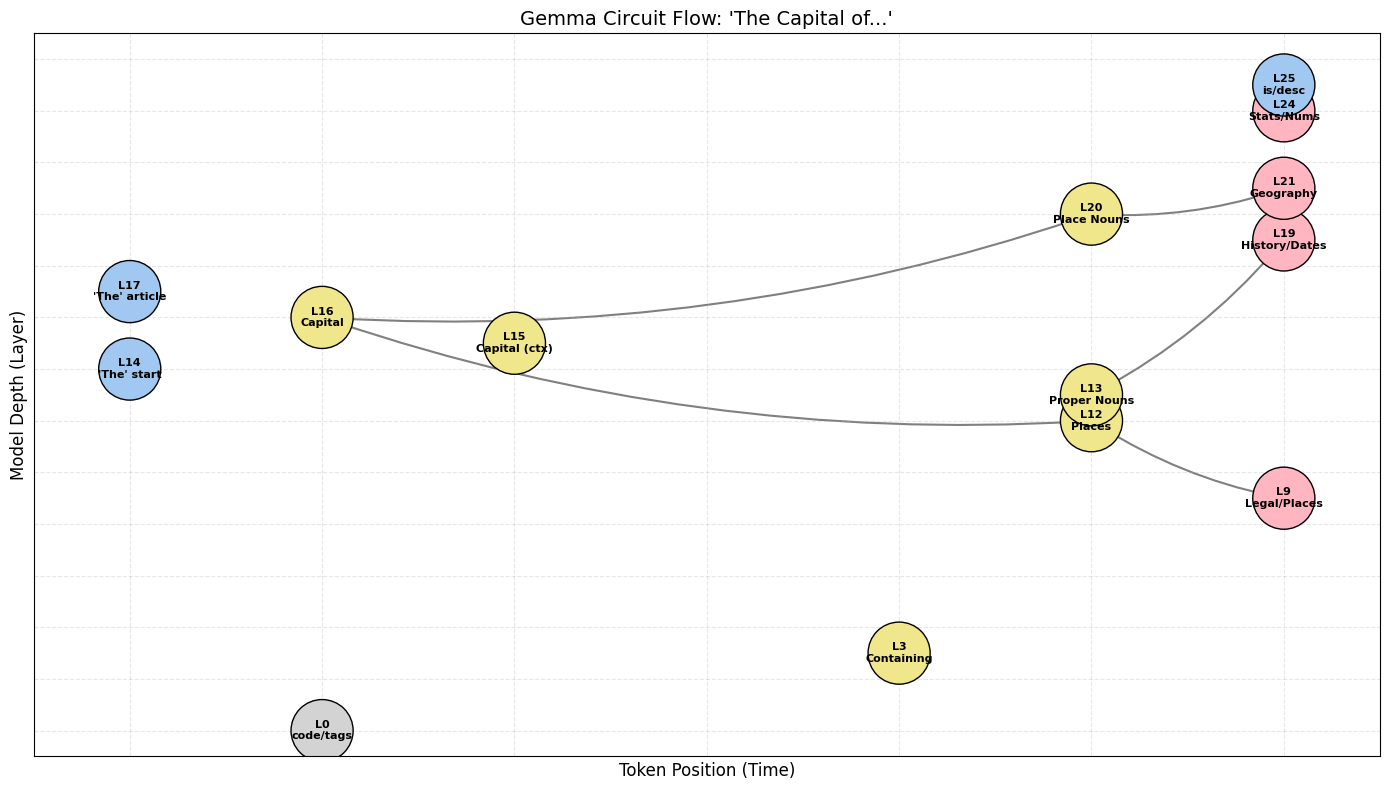

In [45]:
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# 1. DATA (From your validation output)
# ==========================================
prompt_tokens = ['<bos>', 'The', ' capital', ' of', ' state', ' containing', ' Dallas', ' is']

concepts = [
    {"layer": 0, "feat": 14725, "pos": 2, "label": "code/tags", "type": "noise"},
    {"layer": 14, "feat": 8659, "pos": 1, "label": "'The' start", "type": "syntax"},
    {"layer": 17, "feat": 16267, "pos": 1, "label": "'The' article", "type": "syntax"},
    {"layer": 16, "feat": 7171, "pos": 2, "label": "Capital", "type": "semantic"},
    {"layer": 15, "feat": 4494, "pos": 3, "label": "Capital (ctx)", "type": "semantic"},
    {"layer": 3, "feat": 4017, "pos": 5, "label": "Containing", "type": "semantic"},
    {"layer": 12, "feat": 10914, "pos": 6, "label": "Places", "type": "semantic"},
    {"layer": 13, "feat": 5620, "pos": 6, "label": "Proper Nouns", "type": "semantic"},
    {"layer": 20, "feat": 221, "pos": 6, "label": "Place Nouns", "type": "semantic"},
    {"layer": 9, "feat": 185, "pos": 7, "label": "Legal/Places", "type": "reasoning"},
    {"layer": 19, "feat": 13890, "pos": 7, "label": "History/Dates", "type": "reasoning"},
    {"layer": 21, "feat": 15366, "pos": 7, "label": "Geography", "type": "reasoning"},
    {"layer": 24, "feat": 13541, "pos": 7, "label": "Stats/Nums", "type": "reasoning"},
    {"layer": 25, "feat": 11911, "pos": 7, "label": "is/desc", "type": "syntax"},
]

# ==========================================
# 2. SETUP GRAPH
# ==========================================
G = nx.DiGraph()

# Colors for types
colors = {
    "syntax": "#A0C8F0",    # Blue
    "semantic": "#F0E68C",  # Yellow
    "reasoning": "#FFB6C1", # Red
    "noise": "#D3D3D3"      # Grey
}

# Add Nodes with manual (x, y) positions
# X = Token Position, Y = Layer
pos = {}
node_colors = []
labels = {}

for c in concepts:
    node_id = f"L{c['layer']}_P{c['pos']}"
    
    # Add node
    G.add_node(node_id)
    
    # Set position: X is token index, Y is layer number
    pos[node_id] = (c['pos'], c['layer'])
    
    # Store attributes
    node_colors.append(colors.get(c['type'], "white"))
    labels[node_id] = f"L{c['layer']}\n{c['label']}"

# ==========================================
# 3. DRAWING
# ==========================================
plt.figure(figsize=(14, 8))

# Draw the Grid (Layers vs Tokens)
plt.grid(True, linestyle='--', alpha=0.3)

# Draw Edges (Logical Flow)
# We draw arrows to show information moving forward in time
edges = [
    # Capital context flowing to Dallas
    ("L16_P2", "L12_P6"), 
    ("L16_P2", "L20_P6"),
    
    # Dallas flowing to the final "is" (Reasoning)
    ("L20_P6", "L21_P7"),
    ("L12_P6", "L9_P7"),
    ("L13_P6", "L19_P7"),
    
    # History flowing to final answer (Implied)
    ("L19_P7", "L21_P7") 
]
G.add_edges_from(edges)

# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, edgecolors='black')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20, width=1.5, connectionstyle="arc3,rad=0.1")

# Draw Labels
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight="bold")

# ==========================================
# 4. FORMATTING THE AXES
# ==========================================
# Set X-ticks to be the actual words
plt.xticks(range(len(prompt_tokens)), [f"{i}: {t}" for i, t in enumerate(prompt_tokens)], rotation=0, fontsize=10)
plt.yticks(range(0, 27, 2), [f"Layer {i}" for i in range(0, 27, 2)])

plt.title("Gemma Circuit Flow: 'The Capital of...'", fontsize=14)
plt.xlabel("Token Position (Time)", fontsize=12)
plt.ylabel("Model Depth (Layer)", fontsize=12)
plt.ylim(-1, 27)
plt.xlim(0.5, 7.5) # Zoom in on the relevant part (skip <bos>)

plt.tight_layout()
plt.show()